In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [3]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [4]:
df=pd.read_csv("C:/Users/dell/Desktop/Loan_Default_Risk_Prediction/data/processed/loan_feature_engineered.csv")

In [5]:
X=df.drop('Loan_Status',axis=1)

y=df['Loan_Status']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
scaler = StandardScaler()

In [8]:
numerical_features = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

In [9]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [10]:
model_scaled = LogisticRegression(max_iter=1000)

model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))

Accuracy: 0.8617886178861789


In [12]:
dt_model = DecisionTreeClassifier(random_state=42)

In [13]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
y_pred_dt = dt_model.predict(X_test)

In [15]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.7398373983739838


In [16]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[24 14]
 [18 67]]


In [17]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.57      0.63      0.60        38
           1       0.83      0.79      0.81        85

    accuracy                           0.74       123
   macro avg       0.70      0.71      0.70       123
weighted avg       0.75      0.74      0.74       123



In [18]:
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)

print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")
print(f"ROC AUC   : {roc_auc_dt:.4f}")

Precision : 0.8272
Recall    : 0.7882
F1 Score  : 0.8072
ROC AUC   : 0.7099


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [20]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8211382113821138


In [21]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[23 15]
 [ 7 78]]


In [22]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.77      0.61      0.68        38
           1       0.84      0.92      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.76      0.78       123
weighted avg       0.82      0.82      0.81       123



In [23]:
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)

print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC AUC   : {roc_auc_rf:.4f}")

Precision : 0.8387
Recall    : 0.9176
F1 Score  : 0.8764
ROC AUC   : 0.7615


In [24]:
from xgboost import XGBClassifier

In [25]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [26]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [27]:
y_pred_xgb = xgb_model.predict(X_test)

In [28]:
accuracy_xgb=accuracy_score(y_test,y_pred_xgb)
print('XGBoost Accuracy;',accuracy_xgb)

XGBoost Accuracy; 0.7886178861788617


In [29]:
cm_xgb=confusion_matrix(y_test,y_pred_xgb)
print(cm_xgb)

[[23 15]
 [11 74]]


In [30]:
cl_xgb=classification_report(y_test,y_pred_xgb)
print(cl_xgb)

              precision    recall  f1-score   support

           0       0.68      0.61      0.64        38
           1       0.83      0.87      0.85        85

    accuracy                           0.79       123
   macro avg       0.75      0.74      0.74       123
weighted avg       0.78      0.79      0.79       123



In [31]:
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)

print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")
print(f"ROC AUC   : {roc_auc_xgb:.4f}")

Precision : 0.8315
Recall    : 0.8706
F1 Score  : 0.8506
ROC AUC   : 0.7379


In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [34]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [35]:
grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [36]:
print(grid_search.best_params_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [37]:
best_rf = grid_search.best_estimator_

In [38]:
y_pred_best = best_rf.predict(X_test)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.8536585365853658
[[21 17]
 [ 1 84]]
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [40]:
print(grid_search.best_score_)

0.8004122861265719


In [41]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [42]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [43]:
grid_search.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [44]:
print(grid_search.best_params_)

{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [57]:
best_xgb = grid_search.best_estimator_

In [59]:
y_pred_best = best_xgb.predict(X_test)

In [60]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.8617886178861789
[[22 16]
 [ 1 84]]
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [61]:
print(grid_search.best_score_)

0.7983920841063699


In [49]:
feature_importance = best_rf.feature_importances_

In [50]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

In [51]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [52]:
importance_df

,Feature,Importance
9,Credit_History,0.493835
6,CoapplicantIncome,0.056513
3,Education,0.051915
5,ApplicantIncome,0.049876
10,Property_Area_Semiurban,0.049057
1,Married,0.047573
7,LoanAmount,0.047270
8,Loan_Amount_Term,0.046751
2,Dependents,0.040797
11,Property_Area_Urban,0.040346


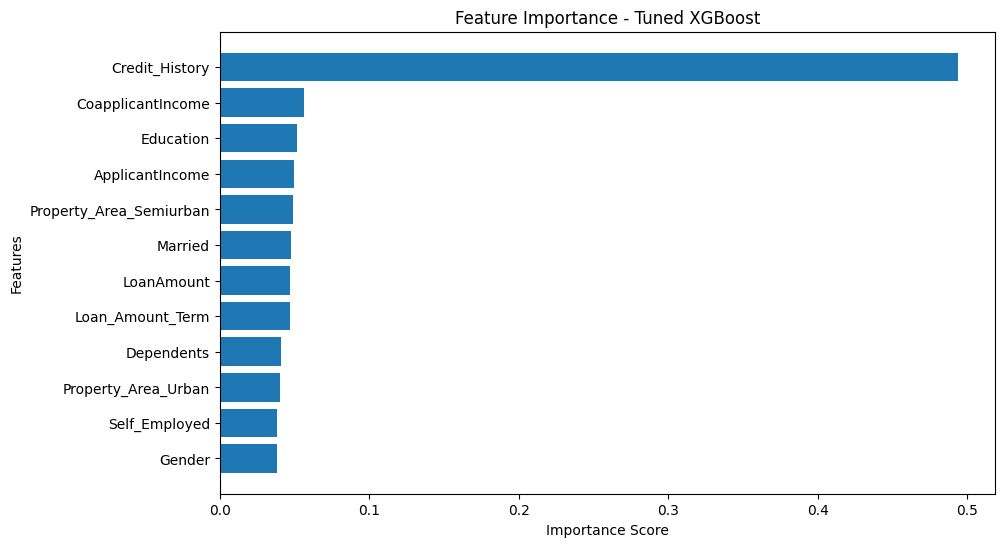

In [53]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Tuned XGBoost")

plt.gca().invert_yaxis()

plt.show()

In [54]:
import joblib

In [62]:
joblib.dump(best_xgb, "C:/Users/dell/Desktop/Loan_Default_Risk_Prediction/models/loan_model.pkl")

['C:/Users/dell/Desktop/Loan_Default_Risk_Prediction/models/loan_model.pkl']

In [63]:
print("Model saved successfully!")

Model saved successfully!


In [64]:
import os

os.listdir("../models")

['loan_model.pkl']

In [65]:
loaded_model = joblib.load("../models/loan_model.pkl")

In [66]:
print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


In [67]:
prediction = loaded_model.predict(X_test)

print(prediction[:10])

[0 1 1 1 1 1 1 1 1 1]


In [68]:
from sklearn.metrics import accuracy_score

loaded_prediction = loaded_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, loaded_prediction))

Accuracy: 0.8617886178861789


In [69]:
feature_names = X_train.columns.tolist()

joblib.dump(feature_names,
            "../models/feature_names.pkl")

['../models/feature_names.pkl']

In [70]:
os.listdir("../models")

['feature_names.pkl', 'loan_model.pkl']